# FastAPI Serving and Concurrency Experiments

This notebook packages the tuned IMDB linear SVM from the previous task, validates its FastAPI contract, and measures how 1,000 local inference requests behave as parallelism increases from 5 to 100. The benchmark uses one Uvicorn worker so the experiment isolates request concurrency rather than adding process-level scaling.

In [1]:
from pathlib import Path
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import Markdown, display

current_path = Path.cwd().resolve()
repository_root = next(
    (
        path
        for path in (current_path, *current_path.parents)
        if (path / 'phase-1-machine-learning-nlp').is_dir()
    ),
    None,
)
if repository_root is None:
    raise FileNotFoundError('Could not locate the repository root.')

task_root = repository_root / 'phase-1-machine-learning-nlp' / '12-fastapi-serving'
source_directory = task_root / 'src'
sys.path.insert(0, str(source_directory))

gpu_check = subprocess.run(
    ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
    capture_output=True,
    text=True,
    check=False,
)
detected_gpu = gpu_check.stdout.strip() if gpu_check.returncode == 0 else 'No CUDA GPU detected'
print(f'Detected GPU: {detected_gpu}')
print('Execution device: CPU because scikit-learn LinearSVC does not use CUDA.')

Detected GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Execution device: CPU because scikit-learn LinearSVC does not use CUDA.


## Train and package the model

The final serving pipeline keeps the previous task's preprocessing, regex tokenizer, custom sparse TF-IDF vectorizer, and validation-selected `C=1` linear SVM. It is refitted on the 80% development split and evaluated once on the untouched 20% test split. The serialized model is intentionally ignored by Git.

In [2]:
from training import train_and_save_model

model_summary = train_and_save_model()
display(pd.Series(model_summary, name='value').to_frame())

,value
random_seed,42.000000
development_reviews,39665.000000
test_reviews,9917.000000
vocabulary_size,30000.000000
selected_C,1.000000
training_seconds,26.629500
test_accuracy,0.894525
test_precision,0.888823
test_recall,0.902753
test_f1,0.895734


## Validate the API contract

The model is loaded once during application startup. `/health` reports readiness, while `/predict` accepts one nonblank review and returns its sentiment and signed SVM decision score.

In [3]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    from fastapi.testclient import TestClient
from api import app

with TestClient(app) as test_client:
    health_response = test_client.get('/health')
    positive_response = test_client.post(
        '/predict',
        json={'text': 'A moving story with excellent performances.'},
    )
    negative_response = test_client.post(
        '/predict',
        json={'text': 'A dull and painfully predictable film.'},
    )
    invalid_response = test_client.post('/predict', json={'text': '   '})

assert health_response.json() == {'status': 'ok', 'model_loaded': True}
assert positive_response.json()['predicted_sentiment'] == 'positive'
assert negative_response.json()['predicted_sentiment'] == 'negative'
assert invalid_response.status_code == 422

api_validation = pd.DataFrame(
    [
        {'case': 'health', 'status': health_response.status_code, 'response': health_response.json()},
        {'case': 'positive example', 'status': positive_response.status_code, 'response': positive_response.json()},
        {'case': 'negative example', 'status': negative_response.status_code, 'response': negative_response.json()},
        {'case': 'blank input', 'status': invalid_response.status_code, 'response': invalid_response.json()},
    ]
)
display(api_validation)

,case,status,response
0,health,200,"{'status': 'ok', 'model_loaded': True}"
1,positive example,200,{'text': 'A moving story with excellent perfor...
2,negative example,200,{'text': 'A dull and painfully predictable fil...
3,blank input,422,"{'detail': [{'type': 'value_error', 'loc': ['b..."


## Concurrency and throughput

Each row measures exactly 1,000 successful POST requests over loopback HTTP. One warm-up request is excluded at every parallelism level. Reusing connections reduces setup noise, and the same ten short reviews are repeated so workload content stays constant.

In [4]:
from benchmark import RESULTS_PATH, run_benchmark

server = subprocess.Popen(
    [
        sys.executable,
        '-m',
        'uvicorn',
        'api:app',
        '--host',
        '127.0.0.1',
        '--port',
        '8765',
        '--workers',
        '1',
        '--log-level',
        'warning',
    ],
    cwd=source_directory,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.STDOUT,
    creationflags=getattr(subprocess, 'CREATE_NO_WINDOW', 0),
)

try:
    for attempt in range(60):
        try:
            ready = requests.get('http://127.0.0.1:8765/health', timeout=1)
            if ready.status_code == 200:
                break
        except requests.RequestException:
            time.sleep(0.25)
    else:
        raise RuntimeError('The local API did not become ready.')

    benchmark_results = await run_benchmark(
        url='http://127.0.0.1:8765/predict',
        concurrency_levels=(5, 10, 20, 40, 60, 80, 100),
        total_requests=1000,
    )
finally:
    server.terminate()
    try:
        server.wait(timeout=10)
    except subprocess.TimeoutExpired:
        server.kill()

RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
benchmark_results.to_csv(RESULTS_PATH, index=False)
display(benchmark_results.style.format({
    'total_seconds': '{:.3f}',
    'throughput_requests_per_second': '{:.2f}',
    'mean_latency_ms': '{:.2f}',
    'p95_latency_ms': '{:.2f}',
}))

,parallel_requests,total_requests,total_seconds,throughput_requests_per_second,mean_latency_ms,p95_latency_ms,successful_requests
0,5,1000,4.439,225.28,20.71,39.21,1000
1,10,1000,6.242,160.20,60.43,144.66,1000
2,20,1000,6.775,147.60,130.70,314.88,1000
3,40,1000,6.806,146.92,262.31,758.75,1000
4,60,1000,6.920,144.51,388.96,1219.69,1000
5,80,1000,8.965,111.55,688.07,2151.82,1000
6,100,1000,7.459,134.07,708.96,2087.40,1000


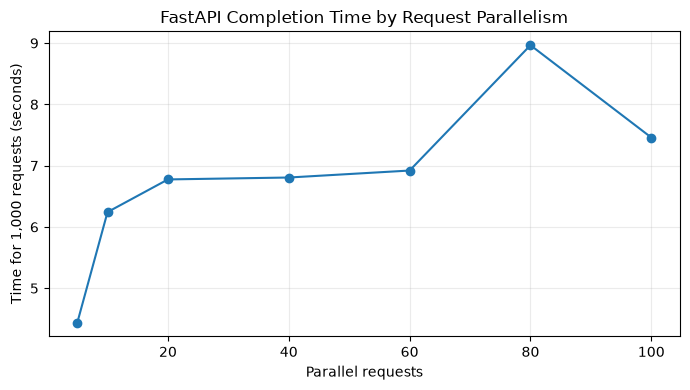

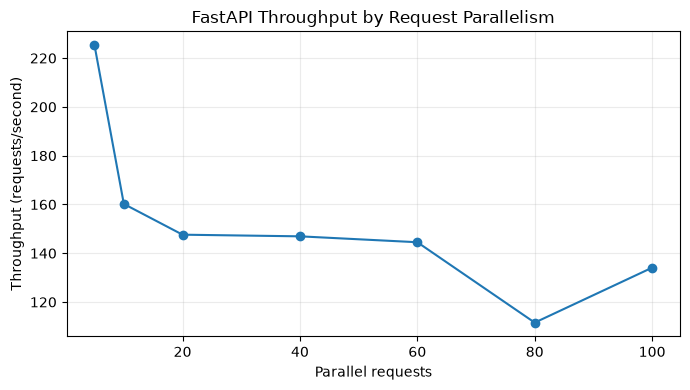

In [5]:
figures_directory = task_root / 'reports' / 'figures'
figures_directory.mkdir(parents=True, exist_ok=True)

fig, axis = plt.subplots(figsize=(7, 4))
axis.plot(benchmark_results['parallel_requests'], benchmark_results['total_seconds'], marker='o')
axis.set(
    xlabel='Parallel requests',
    ylabel='Time for 1,000 requests (seconds)',
    title='FastAPI Completion Time by Request Parallelism',
)
axis.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(figures_directory / 'total-time-by-concurrency.png', dpi=150)
plt.show()

fig, axis = plt.subplots(figsize=(7, 4))
axis.plot(
    benchmark_results['parallel_requests'],
    benchmark_results['throughput_requests_per_second'],
    marker='o',
)
axis.set(
    xlabel='Parallel requests',
    ylabel='Throughput (requests/second)',
    title='FastAPI Throughput by Request Parallelism',
)
axis.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(figures_directory / 'throughput-by-concurrency.png', dpi=150)
plt.show()

In [6]:
best_row = benchmark_results.loc[
    benchmark_results['throughput_requests_per_second'].idxmax()
]
display(Markdown(
    '## Observations\n\n'
    f"- Maximum measured throughput was `{best_row['throughput_requests_per_second']:.2f}` requests/second "
    f"at `{int(best_row['parallel_requests'])}` parallel requests.\n"
    f"- That run completed 1,000 requests in `{best_row['total_seconds']:.3f}` seconds with "
    f"`{best_row['p95_latency_ms']:.2f}` ms p95 request latency.\n"
    '- Increasing concurrency can improve throughput while the server has idle capacity, but latency grows once CPU work and scheduling become saturated. '
    'These loopback results describe this machine and single-worker setup; they are not a production capacity guarantee.'
))

## Observations

- Maximum measured throughput was `225.28` requests/second at `5` parallel requests.
- That run completed 1,000 requests in `4.439` seconds with `39.21` ms p95 request latency.
- Increasing concurrency can improve throughput while the server has idle capacity, but latency grows once CPU work and scheduling become saturated. These loopback results describe this machine and single-worker setup; they are not a production capacity guarantee.